# 01 · Data Preparation & Exploratory Analysis

**Amazon Reviews 2023 — Electronics** · Real-time recommendation system

This notebook is the first stage of the pipeline. It:

1. Loads the **subsampled** interaction + item data (produced by `src/recsys/data.py`).
2. Explores the data: sparsity, rating distribution, the long tail, temporal patterns.
3. Defines what counts as a **positive interaction**.
4. Performs a **time-based train / val / test split**.

> **Why the data is already subsampled.** The raw `Electronics.jsonl` is **22.6 GB** (~44M reviews) — impossible to load in memory. We stream it once with `src/recsys/data.py`, keep the **most recent 5,000,000 interactions**, apply **5-core** filtering, and write small Parquet files. This notebook consumes those.

> **Subsampling strategy.** Most-recent-5M by `timestamp` → positive = `rating >= 4` → iterative 5-core on the positive-interaction graph. Result: **320,184 interactions, 25,546 users, 20,450 items** spanning 2022-04 → 2023-09. The 5-core step is aggressive on Amazon's long tail (most users review once), but leaves a clean, dense dataset where every user/item has enough signal to learn an embedding.

## 0 · Setup

On Colab, mount Drive and point `DATA_DIR` at the folder holding the Parquet files. Locally, the defaults already work.

In [1]:
import sys, os
from pathlib import Path

# --- Colab: mount Drive so checkpoints/data persist across session timeouts ---
try:
    import google.colab  # noqa
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT = Path('/content/drive/MyDrive/rec-system')  # <-- adjust to your Drive path
except ImportError:
    PROJECT = Path('..').resolve()  # running locally from notebooks/

DATA_DIR = PROJECT / 'data'
sys.path.insert(0, str(PROJECT / 'src'))
print('Project :', PROJECT)
print('Data    :', DATA_DIR, '(exists:', DATA_DIR.exists(), ')')

Project : F:\Rec_System
Data    : F:\Rec_System\data (exists: True )


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 60)
plt.rcParams['figure.figsize'] = (8, 4)

## 1 · Load the subsampled data

In [3]:
inter = pd.read_parquet(DATA_DIR / 'interactions.parquet')
items = pd.read_parquet(DATA_DIR / 'items.parquet')

inter['datetime'] = pd.to_datetime(inter['timestamp'], unit='ms')
print(f'interactions : {len(inter):,}')
print(f'users        : {inter.user_idx.nunique():,}')
print(f'items        : {inter.item_idx.nunique():,}')
print(f'date range   : {inter.datetime.min().date()} -> {inter.datetime.max().date()}')
inter.head()

interactions : 320,184
users        : 25,546
items        : 20,450
date range   : 2022-04-26 -> 2023-09-06


,user_idx,item_idx,user_id,parent_asin,rating,timestamp,verified_purchase,positive,datetime
0,9900,5035,AFLCRXIIZQLG3FIRJXYACRA7OFEA,B09XCSPJ3D,5.0,1651010487199,False,True,2022-04-26 22:01:27.199
1,7086,3670,AF55NNZFMC4T24X3DXIYQLDMZM7A,B09MRX9CW8,4.0,1651010499311,False,True,2022-04-26 22:01:39.311
2,8928,1314,AFGR7XHQLLHCHHMVYFPDFSTTC5TA,B082M4L6J6,5.0,1651010858453,True,True,2022-04-26 22:07:38.453
3,8928,1724,AFGR7XHQLLHCHHMVYFPDFSTTC5TA,B08DLSLCF3,5.0,1651010924595,True,True,2022-04-26 22:08:44.595
4,8928,783,AFGR7XHQLLHCHHMVYFPDFSTTC5TA,B07KTYJ769,5.0,1651010982008,True,True,2022-04-26 22:09:42.008


Each row is one review. `user_idx` / `item_idx` are contiguous integer ids (needed for embedding lookups later); `positive` flags `rating >= 4`. The item table carries the metadata the webapp displays.

In [4]:
items[['item_idx', 'title', 'category', 'price', 'image_url']].head()

,item_idx,title,category,price,image_url
0,15725,PNY 1TB PRO Elite Class 10 U3 V30 microSDXC Flash Memory...,Micro SD Cards,109.99,https://m.media-amazon.com/images/I/61jajvgWBzL._AC_SL10...
1,12268,"LENTION USB C Docking Station, 10 Gbps USB C&USB A Ports...",Docking Stations,89.99,https://m.media-amazon.com/images/I/51jlWbhpjRL._AC_SL15...
2,14315,"PHIXERO SATA to USB 3.0 Adapter for 2.5"" SSD/HDD with Pr...",SATA Cables,10.99,https://m.media-amazon.com/images/I/61fsLHnM36L._AC_SL15...
3,8282,"Aiminu USB C to Lightning Cable 6ft 2Pack, Fast iPhone C...",Lightning Cables,10.99,https://m.media-amazon.com/images/I/71ZHzM2E36L._AC_SL15...
4,7807,KKstorm School Headset for School: Student Headphones Bu...,Over-Ear Headphones,19.64,https://m.media-amazon.com/images/I/71NlNUwtABL._AC_SL15...


## 2 · Sparsity

Sparsity = fraction of the user×item matrix that is **empty**. Recommenders live or die by how they handle this, almost every cell is unobserved.

In [5]:
n_users, n_items = inter.user_idx.nunique(), inter.item_idx.nunique()
density = len(inter) / (n_users * n_items)
print(f'matrix       : {n_users:,} users x {n_items:,} items = {n_users*n_items:,} cells')
print(f'observed     : {len(inter):,}')
print(f'density      : {density:.6%}')
print(f'sparsity     : {1 - density:.4%}')

matrix       : 25,546 users x 20,450 items = 522,415,700 cells
observed     : 320,184
density      : 0.061289%
sparsity     : 99.9387%


> **Interpretation.** At ~99.94% sparsity, a user has rated ~13 of 20,450 items on average. This is why we need latent factors (MF / two-tower) rather than memorising the matrix, and why popularity is such a strong baseline  with this little signal, 'what's popular' is hard to beat.

## 3 · Rating distribution & the positive threshold

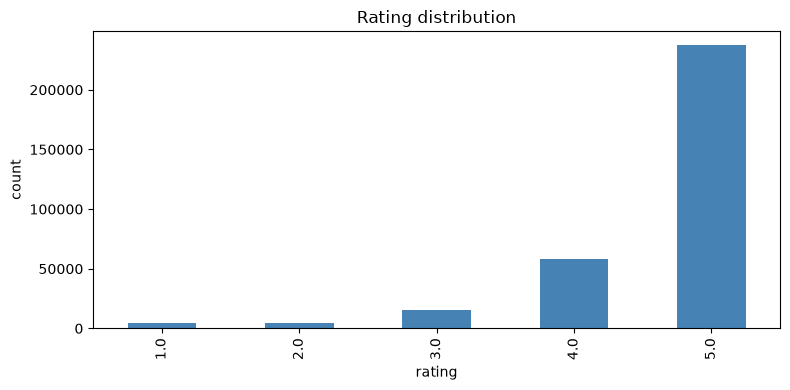

rating
1.0    0.015
2.0    0.015
3.0    0.048
4.0    0.182
5.0    0.741
Name: proportion, dtype: float64

positive (rating>=4): 92.2%


In [6]:
ax = inter.rating.value_counts().sort_index().plot(kind='bar', color='steelblue')
ax.set(title='Rating distribution', xlabel='rating', ylabel='count')
plt.tight_layout(); plt.show()

print(inter.rating.value_counts(normalize=True).sort_index().round(3))
print(f"\npositive (rating>=4): {inter.positive.mean():.1%}")

> **Interpretation & design decision.** The distribution is heavily skewed to 4–5★ — typical Amazon *J-shape* (people mostly review things they liked). We define a **positive interaction as `rating >= 4`**. Ratings of 1–3 are kept in the table (useful for ranking features like 'user average rating') but are **not** training targets for retrieval. ~92% of interactions are positive, so the retrieval models learn from a strong-preference signal.

## 4 · The long tail

How concentrated is interaction volume across items and users?

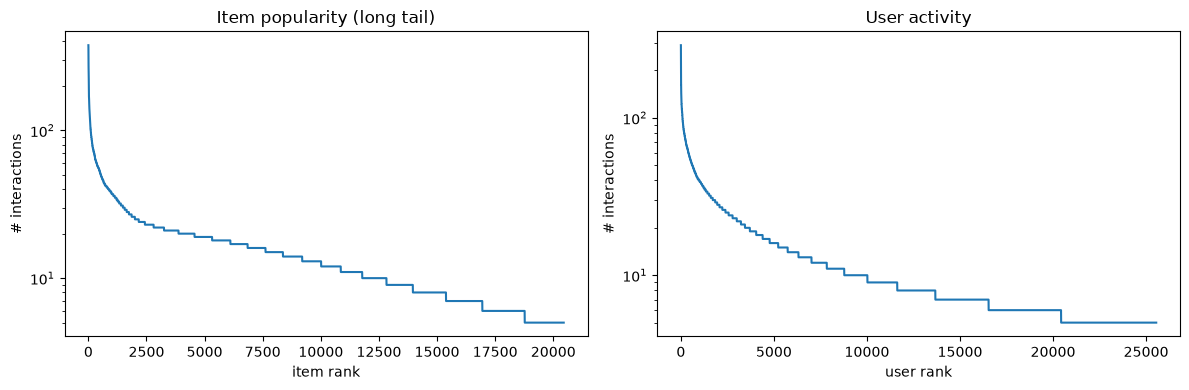

Top 5,059 items (24.7%) account for 50% of all interactions.


In [7]:
item_pop = inter.groupby('item_idx').size().sort_values(ascending=False).values
user_act = inter.groupby('user_idx').size().sort_values(ascending=False).values

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(np.arange(len(item_pop)), item_pop); ax[0].set(title='Item popularity (long tail)',
           xlabel='item rank', ylabel='# interactions', yscale='log')
ax[1].plot(np.arange(len(user_act)), user_act); ax[1].set(title='User activity',
           xlabel='user rank', ylabel='# interactions', yscale='log')
plt.tight_layout(); plt.show()

cum = np.cumsum(item_pop) / item_pop.sum()
top1 = (cum <= 0.5).sum()
print(f'Top {top1:,} items ({top1/len(item_pop):.1%}) account for 50% of all interactions.')

> **Interpretation.** A small head of items captures a large share of interactions: the classic long tail. This motivates **Catalog Coverage** as a metric: a recommender that only ever suggests the head looks accurate but is useless for discovery. We report coverage alongside accuracy for every model.

In [8]:
print('User activity (post 5-core):')
print(pd.Series(user_act).describe().round(1))
print('\nCold-start-ish users (5-6 interactions):',
      int(((user_act >= 5) & (user_act <= 6)).sum()))

User activity (post 5-core):
count    25546.0
mean        12.5
std         13.6
min          5.0
25%          6.0
50%          8.0
75%         13.0
max        289.0
dtype: float64

Cold-start-ish users (5-6 interactions): 9011


These low-activity users are exactly the **cold-start** cohort we break out later in the analysis (performance by user activity level).

## 5 · Temporal patterns

The split is time-based, so we must understand how volume evolves over the window.

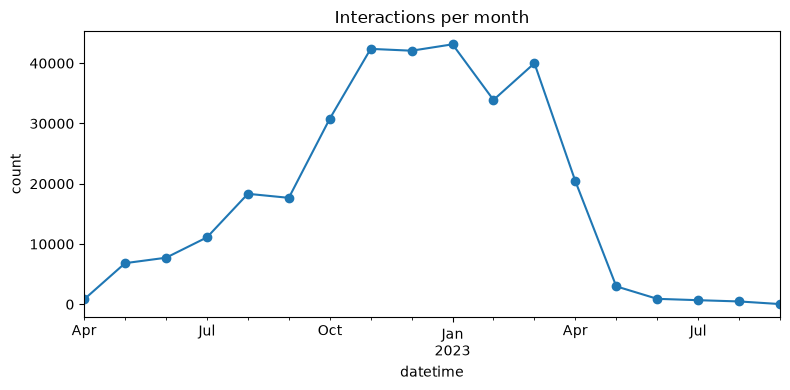

window: 2022-04-26 -> 2023-09-06


In [9]:
monthly = inter.set_index('datetime').resample('MS').size()
ax = monthly.plot(marker='o'); ax.set(title='Interactions per month', ylabel='count')
plt.tight_layout(); plt.show()
print('window:', inter.datetime.min().date(), '->', inter.datetime.max().date())

> **Interpretation.** Volume grows toward the recent end (the most-recent-5M subsample biases toward late dates). A **time-based split** therefore puts the busiest, most recent period in test — a realistic, harder evaluation than a random split would give.

## 6 · Time-based split

 We use a single global wall-clock cutoff — train on the past, evaluate on the future.

- **Test**  = most recent 15% of interactions (by time)
- **Val**   = most recent 15% of what remains (for hyperparameter tuning — never touch test)
- **Train** = everything before that

The test-period interactions also serve as each user's **recent history** in the webapp, simulating a live deployment serving activity the model wasn't trained on.

In [10]:
from recsys.data import time_based_split

train, val, test = time_based_split(inter, test_frac=0.15, val_frac=0.15)

def span(d): return f"{d.datetime.min().date()} -> {d.datetime.max().date()}"
for name, d in [('train', train), ('val', val), ('test', test)]:
    print(f'{name:5s}: {len(d):>7,} rows | {span(d)}')

assert train.timestamp.max() <= val.timestamp.min(), 'val must be strictly after train'
assert val.timestamp.max()   <= test.timestamp.min(), 'test must be strictly after val'
print('\nOK: strictly increasing time boundaries (no leakage).')

train: 231,332 rows | 2022-04-26 -> 2023-02-10
val  :  40,824 rows | 2023-02-10 -> 2023-03-14
test :  48,028 rows | 2023-03-14 -> 2023-09-06

OK: strictly increasing time boundaries (no leakage).


### Evaluation-ready ground truth

For retrieval metrics (Recall@K, NDCG@K) we only score **positive** test interactions, and only for users the model has seen in train (they need an embedding). We build the per-user ground-truth item sets now and save them for the baseline / retrieval notebooks.

In [11]:
train_users = set(train.user_idx.unique())
train_items = set(train.item_idx.unique())

test_pos = test[test.positive & test.user_idx.isin(train_users) & test.item_idx.isin(train_items)]
gt = test_pos.groupby('user_idx')['item_idx'].apply(list)

print(f'evaluable users        : {gt.index.nunique():,}')
print(f'ground-truth positives : {test_pos.shape[0]:,}')
print(f'avg test positives/user: {gt.map(len).mean():.2f}')

evaluable users        : 6,962
ground-truth positives : 16,381
avg test positives/user: 2.35


## 7 · Save splits for downstream notebooks

Every later stage (baselines, MF-BPR, two-tower, ranking) reads these — so they never re-run this notebook. On Colab these land in Drive and survive session timeouts.

In [12]:
SPLIT_DIR = DATA_DIR / 'splits'
SPLIT_DIR.mkdir(exist_ok=True)
train.to_parquet(SPLIT_DIR / 'train.parquet', index=False)
val.to_parquet(SPLIT_DIR / 'val.parquet', index=False)
test.to_parquet(SPLIT_DIR / 'test.parquet', index=False)
gt.to_frame('items').to_parquet(SPLIT_DIR / 'test_ground_truth.parquet')
print('saved ->', SPLIT_DIR)
for p in sorted(SPLIT_DIR.glob('*.parquet')):
    print(' ', p.name, f'{p.stat().st_size/1e6:.2f} MB')

saved -> F:\Rec_System\data\splits
  test.parquet 1.61 MB
  test_ground_truth.parquet 0.10 MB
  train.parquet 5.95 MB
  val.parquet 1.47 MB
